# `Aspergillus niger`

✅ Saved plot to: ./germination_plot_custom_colors.png


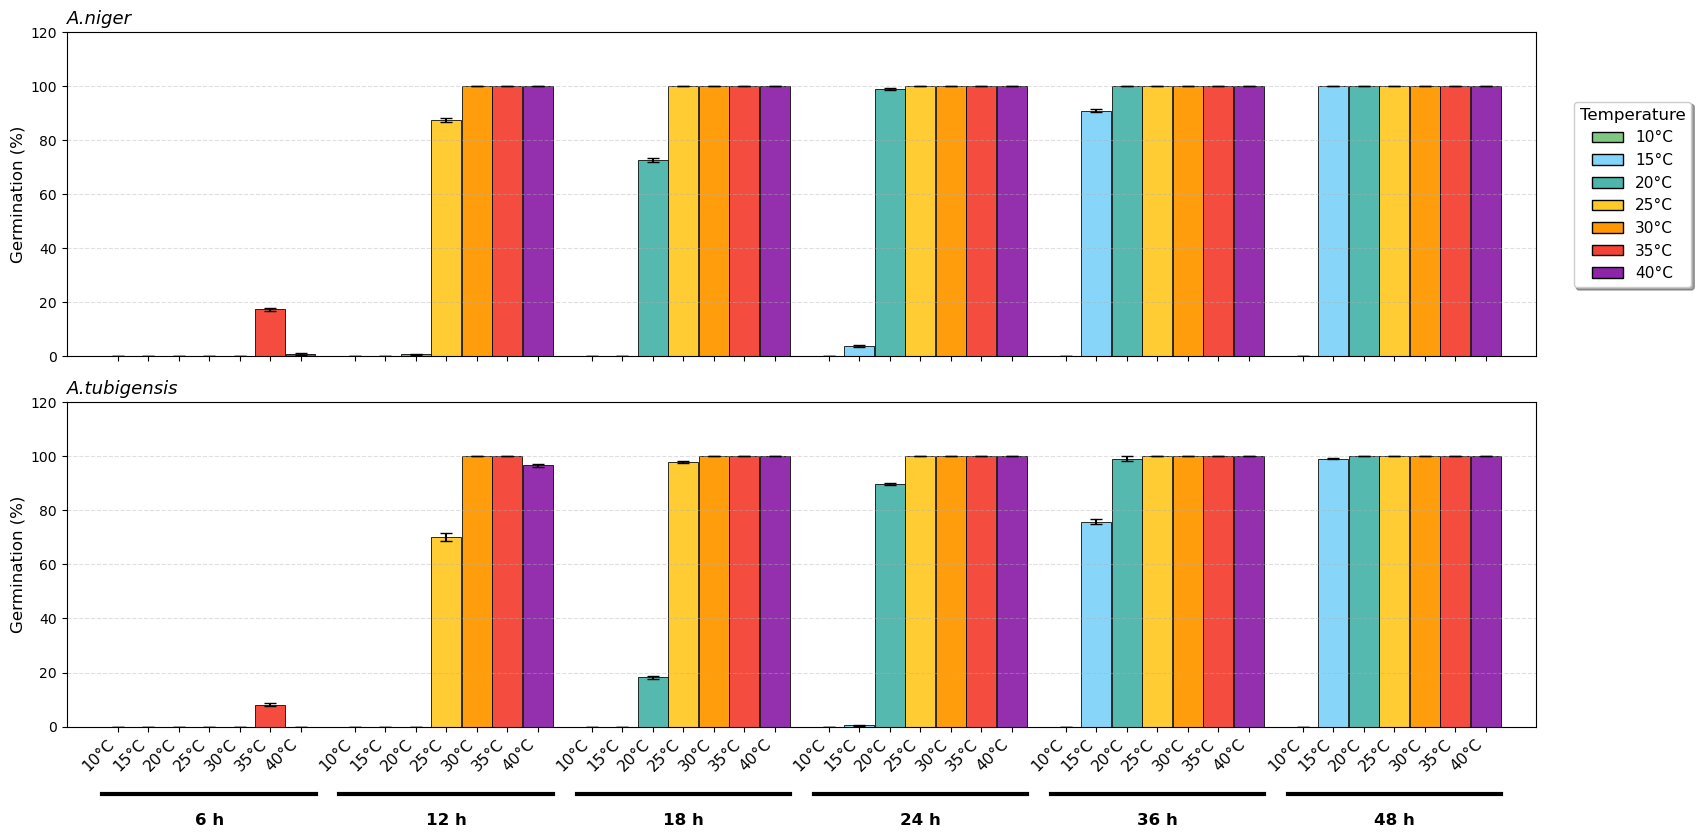

In [2]:
# === germination_plot_custom_colors.py ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === 1. Load the data ===
df = pd.read_excel("./germination_dummy.xlsx")

# === 2. Auto-detect column names ===
def find_col(df_cols, keywords, exclude=None):
    for col in df_cols:
        low = col.lower()
        if exclude and col == exclude:
            continue
        for kw in keywords:
            if kw in low:
                return col
    return None

col_species = find_col(df.columns, ["species", "genotype", "strain", "sample"])
col_temp = find_col(df.columns, ["temperature", "temp", "°c", "c"], exclude=col_species)
col_time = find_col(df.columns, ["incubation", "time", "hours", "hour", "h"])
col_value = find_col(df.columns, ["germination", "germination_%", "germination%", "germination rate"])
col_se = find_col(df.columns, ["se", "std", "stderr", "std_err", "stderror", "standard_error"])

if col_species is None or col_temp is None or col_time is None or col_value is None:
    raise ValueError("Missing one or more key columns. Check your spreadsheet headers.")

if col_se is None:
    df["SE"] = 0.0
    col_se = "SE"

# === 3. Standardize column names ===
rename_map = {
    col_species: "Species",
    col_temp: "Temperature_C",
    col_time: "Incubation_h",
    col_value: "Germination_%",
    col_se: "SE",
}
df = df.rename(columns=rename_map)

# === 4. Clean data ===
for col in ["Temperature_C", "Incubation_h", "Germination_%", "SE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Species", "Temperature_C", "Incubation_h", "Germination_%"]).reset_index(drop=True)

# === 5. Group and setup ===
species_list = sorted(df["Species"].unique().tolist())
times = np.sort(df["Incubation_h"].unique())
temps = np.sort(df["Temperature_C"].unique())

MAX_TEMP_GROUPS = 7
if len(temps) > MAX_TEMP_GROUPS:
    temps = temps[:MAX_TEMP_GROUPS]
    print(f"⚠️ Limited to {MAX_TEMP_GROUPS} lowest temperatures for readability.")

group_centers = np.arange(len(times))
bar_group_width = 0.9
width = bar_group_width / max(1, len(temps))
offsets = (np.arange(len(temps)) - (len(temps) - 1) / 2.0) * width

# === 6. Fixed Temperature Colors ===
temp_color_map = {
    10: "#81C784",  # 🍃 Green
    15: "#81D4FA",  # 🔵 Sky Blue
    20: "#4DB6AC",  # 🟢 Teal
    25: "#FFCA28",  # 🟡 Amber
    30: "#FF9800",  # 🟠 Orange
    35: "#F44336",  # 🔴 Scarlet Red
    40: "#8E24AA",  # 🟣 Violet
}
temp_colors = [temp_color_map.get(int(temp), "#BDBDBD") for temp in temps]  # fallback gray

# === 7. Plot ===
fig, axes = plt.subplots(len(species_list), 1, figsize=(18, 4.2 * len(species_list)), sharex=True, sharey=True)
if len(species_list) == 1:
    axes = [axes]

for ax, sp in zip(axes, species_list):
    subset = df[df["Species"] == sp].copy()
    val_matrix = np.zeros((len(times), len(temps)))
    se_matrix = np.zeros((len(times), len(temps)))

    for i, time in enumerate(times):
        for j, temp in enumerate(temps):
            sel = subset.query("Incubation_h == @time and Temperature_C == @temp")
            val_matrix[i, j] = sel["Germination_%"].mean() if not sel.empty else 0.0
            se_matrix[i, j] = sel["SE"].mean() if not sel.empty else 0.0

    for i in range(len(times)):
        for j in range(len(temps)):
            pos = group_centers[i] + offsets[j]
            ax.bar(
                pos,
                val_matrix[i, j],
                width=width * 0.98,
                color=temp_colors[j],
                yerr=se_matrix[i, j],
                capsize=4,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.95,
            )

    ax.set_ylim(0, 120)
    ax.set_ylabel("Germination (%)", fontsize=12)
    ax.set_title(sp, loc="left", fontstyle="italic", fontsize=13)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# === 8. X-axis labels ===
positions_matrix = (group_centers.reshape(-1, 1) + offsets.reshape(1, -1))
bottom_ticks = positions_matrix.flatten()
bottom_labels = [f"{int(temp)}°C" for _ in range(len(times)) for temp in temps]

axes[-1].set_xticks(bottom_ticks)
axes[-1].set_xticklabels(bottom_labels, rotation=45, ha="right", fontsize=11)
axes[-1].set_xlim(group_centers[0] - 0.6, group_centers[-1] + 0.6)

for i, time in enumerate(times):
    left = group_centers[i] - bar_group_width / 2
    right = group_centers[i] + bar_group_width / 2
    axes[-1].plot([left, right], [-25, -25], color='black', linewidth=3, clip_on=False)
    axes[-1].text(group_centers[i], -32, f"{int(time)} h", ha="center", va="top", fontsize=12, fontweight='bold')

# === 9. Legend ===
legend_elements = [Patch(facecolor=temp_colors[j], edgecolor='black', label=f'{int(temps[j])}°C')
                   for j in range(len(temps))]
axes[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
               title='Temperature', fontsize=11, title_fontsize=12,
               frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0, 0.95, 1])
out_path = "./germination_plot_custom_colors.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"✅ Saved plot to: {out_path}")
plt.show()